# Portfolio Performance & Risk Metrics: AAPL vs. SPY

- **Daily Returns & Cointegration Spread**: Plotting daily simple and log returns and evaluating comovement against the S&P 500.
- **Return Foundations**: Comparing simple returns, log returns, cumulative compounding, and CAGR.
- **Volatility & Drawdowns**: Measuring annualized risk, high-water marks, and peak-to-trough underwater dynamics.
- **Risk-Adjusted Performance**: Balancing returns against total variance (Sharpe) and downside variance (Sortino).
- **Dynamic Performance**: Tracking rolling 30-day Sharpe ratios across evolving market regimes.
- **Tail Risk**: Estimating Value at Risk (VaR) via empirical historical percentiles.
- **Systematic Risk & CAPM**: Decomposing asset returns into market beta ($\beta$) and Jensen's alpha ($\alpha$) via OLS.
- **Advanced Quant Metrics**: Evaluating statistical significance and track-record validity with the Probabilistic Sharpe Ratio (PSR).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy import stats
import yfinance as yf

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

tickers = ['AAPL', 'SPY']
raw_data = yf.download(tickers, start='2021-01-01', end='2025-01-01', auto_adjust=True, progress=False)['Close'].ffill().dropna()
prices = raw_data[['AAPL', 'SPY']]

#IMPORTANT
returns = prices.pct_change().dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()
rf_daily = 0.04 / 252

prices.head()

Ticker,AAPL,SPY
Date,,
2021-01-04,125.632500,341.588684
2021-01-05,127.185791,343.941315
2021-01-06,122.904503,345.997681
2021-01-07,127.098442,351.138275
2021-01-08,128.195465,353.139008


### 1. Daily Simple Returns vs. Log Returns & Cointegration Spread

- Tracks single-period arithmetic returns and continuously compounded log returns.
- Examines the residual spread of AAPL returns relative to the SPY benchmark.
- **Formulas**:
  $$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$
  $$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$
  $$\text{Spread}_t = R_{\text{AAPL}, t} - (\alpha + \beta R_{\text{SPY}, t})$$

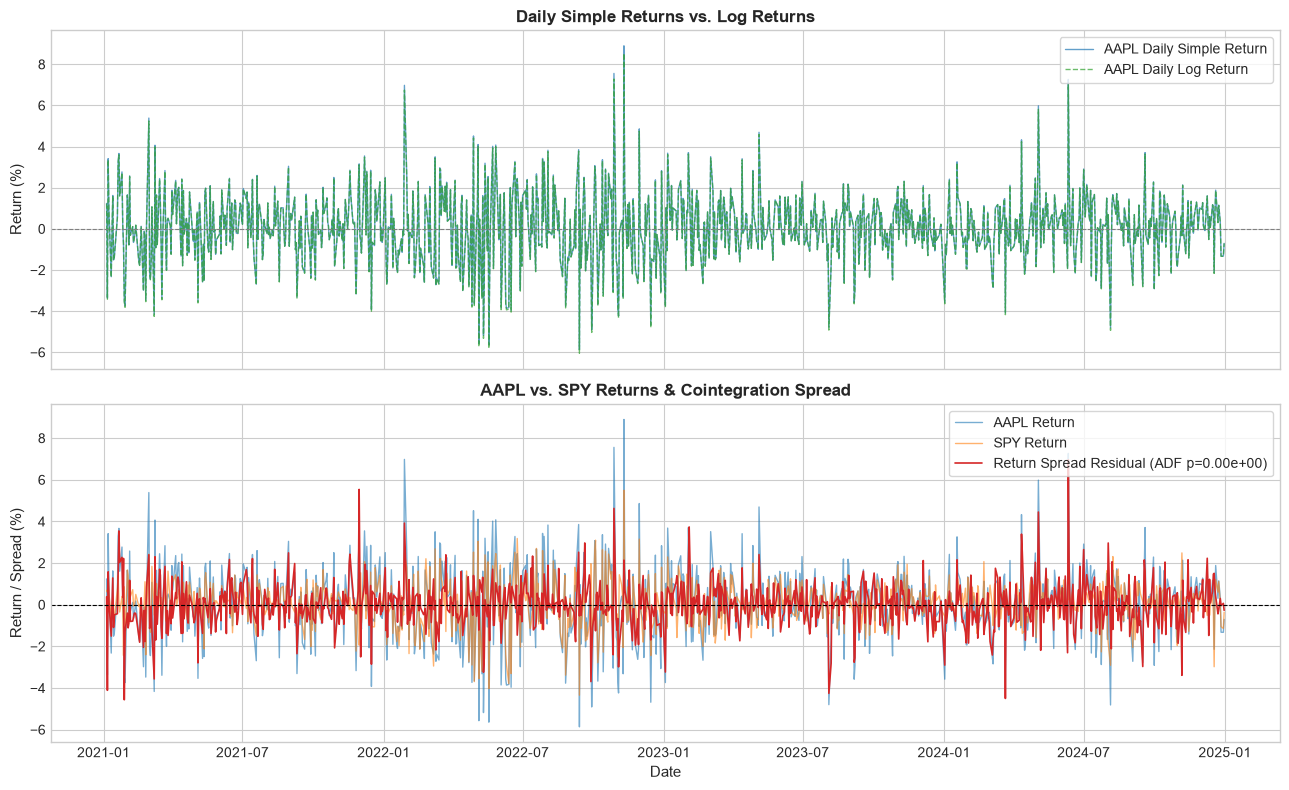

,Series,ADF Statistic,p-value,1% Critical Value,Stationary (p < 0.05)
0,AAPL Simple Return,-23.609,0.000e+00,-3.437,Yes
1,AAPL Log Return,-23.570,0.000e+00,-3.437,Yes
2,SPY Simple Return,-23.425,0.000e+00,-3.437,Yes
3,SPY Log Return,-23.387,0.000e+00,-3.437,Yes
4,Return Cointegration Spread,-23.079,0.000e+00,-3.437,Yes


In [2]:
#IMPORTANT
adf_ret_aapl = adfuller(returns['AAPL'])
adf_log_aapl = adfuller(log_returns['AAPL'])
adf_ret_spy = adfuller(returns['SPY'])
adf_log_spy = adfuller(log_returns['SPY'])

#IMPORTANT
ols_cointeg = sm.OLS(returns['AAPL'], sm.add_constant(returns['SPY'])).fit()
spread_ret = returns['AAPL'] - (ols_cointeg.params['const'] + ols_cointeg.params['SPY'] * returns['SPY'])
adf_spread = adfuller(spread_ret)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1.plot(returns.index, returns['AAPL'] * 100, label='AAPL Daily Simple Return', color='#1f77b4', lw=1, alpha=0.7)
ax1.plot(log_returns.index, log_returns['AAPL'] * 100, label='AAPL Daily Log Return', color='#2ca02c', lw=1, ls='--', alpha=0.7)
ax1.axhline(0, color='gray', ls='--', lw=0.8)
ax1.set_title('Daily Simple Returns vs. Log Returns', fontsize=12, fontweight='bold')
ax1.set_ylabel('Return (%)', fontsize=11)
ax1.legend(loc='upper right', frameon=True)

ax2.plot(returns.index, returns['AAPL'] * 100, label='AAPL Return', color='#1f77b4', lw=1, alpha=0.6)
ax2.plot(returns.index, returns['SPY'] * 100, label='SPY Return', color='#ff7f0e', lw=1, alpha=0.6)
ax2.plot(spread_ret.index, spread_ret * 100, label=f'Return Spread Residual (ADF p={adf_spread[1]:.2e})', color='#d62728', lw=1.2)
ax2.axhline(0, color='black', ls='--', lw=0.8)
ax2.set_title('AAPL vs. SPY Returns & Cointegration Spread', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Return / Spread (%)', fontsize=11)
ax2.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

pd.DataFrame({
    'Series': ['AAPL Simple Return', 'AAPL Log Return', 'SPY Simple Return', 'SPY Log Return', 'Return Cointegration Spread'],
    'ADF Statistic': [round(adf_ret_aapl[0], 3), round(adf_log_aapl[0], 3), round(adf_ret_spy[0], 3), round(adf_log_spy[0], 3), round(adf_spread[0], 3)],
    'p-value': [f"{adf_ret_aapl[1]:.3e}", f"{adf_log_aapl[1]:.3e}", f"{adf_ret_spy[1]:.3e}", f"{adf_log_spy[1]:.3e}", f"{adf_spread[1]:.3e}"],
    '1% Critical Value': [round(adf_ret_aapl[4]['1%'], 3), round(adf_log_aapl[4]['1%'], 3), round(adf_ret_spy[4]['1%'], 3), round(adf_log_spy[4]['1%'], 3), round(adf_spread[4]['1%'], 3)],
    'Stationary (p < 0.05)': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes']
})

### 2. Cumulative Returns & CAGR Compounding

- Cumulative return compounds single-period returns over the full investment horizon.
- Compound Annual Growth Rate (CAGR) computes the constant annualized rate of return equivalent to the total compounding growth.
- **Formulas**:
  $$\text{CumRet}_t = \prod_{\tau=1}^t (1 + R_\tau) - 1$$
  $$\text{CAGR} = \left( \frac{P_T}{P_0} \right)^{\frac{252}{N}} - 1$$

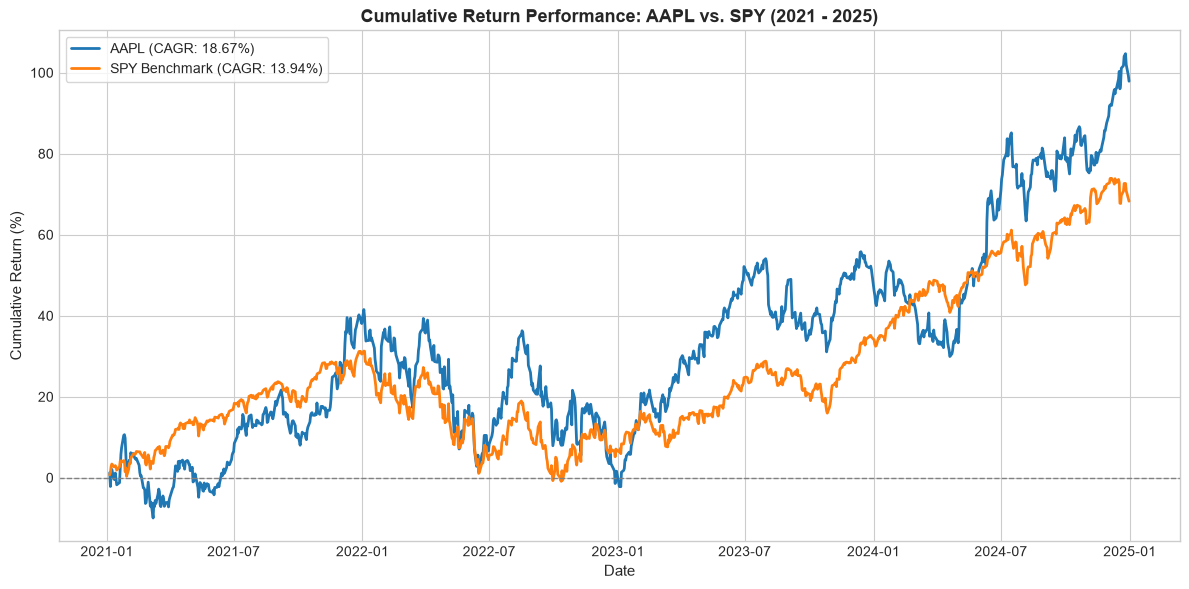

,Total Return (%),CAGR (%)
AAPL,97.89,18.67
SPY,68.27,13.94


In [3]:
#IMPORTANT
cum_returns = (1 + returns).cumprod() - 1

#IMPORTANT
cagr_aapl = (prices['AAPL'].iloc[-1] / prices['AAPL'].iloc[0]) ** (252 / len(prices)) - 1
cagr_spy = (prices['SPY'].iloc[-1] / prices['SPY'].iloc[0]) ** (252 / len(prices)) - 1

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_returns.index, cum_returns['AAPL'] * 100, label=f"AAPL (CAGR: {cagr_aapl * 100:.2f}%)", color='#1f77b4', lw=2)
ax.plot(cum_returns.index, cum_returns['SPY'] * 100, label=f"SPY Benchmark (CAGR: {cagr_spy * 100:.2f}%)", color='#ff7f0e', lw=2)
ax.set_title('Cumulative Return Performance: AAPL vs. SPY (2021 - 2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Cumulative Return (%)', fontsize=11)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

pd.DataFrame({
    'Total Return (%)': (cum_returns.iloc[-1] * 100).round(2),
    'CAGR (%)': pd.Series({'AAPL': cagr_aapl * 100, 'SPY': cagr_spy * 100}).round(2)
})

### 3. Annualized Volatility

- Measures the dispersion of daily returns around their mean, scaled to an annual horizon assuming 252 trading days.
- High volatility indicates larger uncertainty and wider price swings.
- **Formula**:
  $$\sigma_{\text{ann}} = \sigma_{\text{daily}} \times \sqrt{252}$$

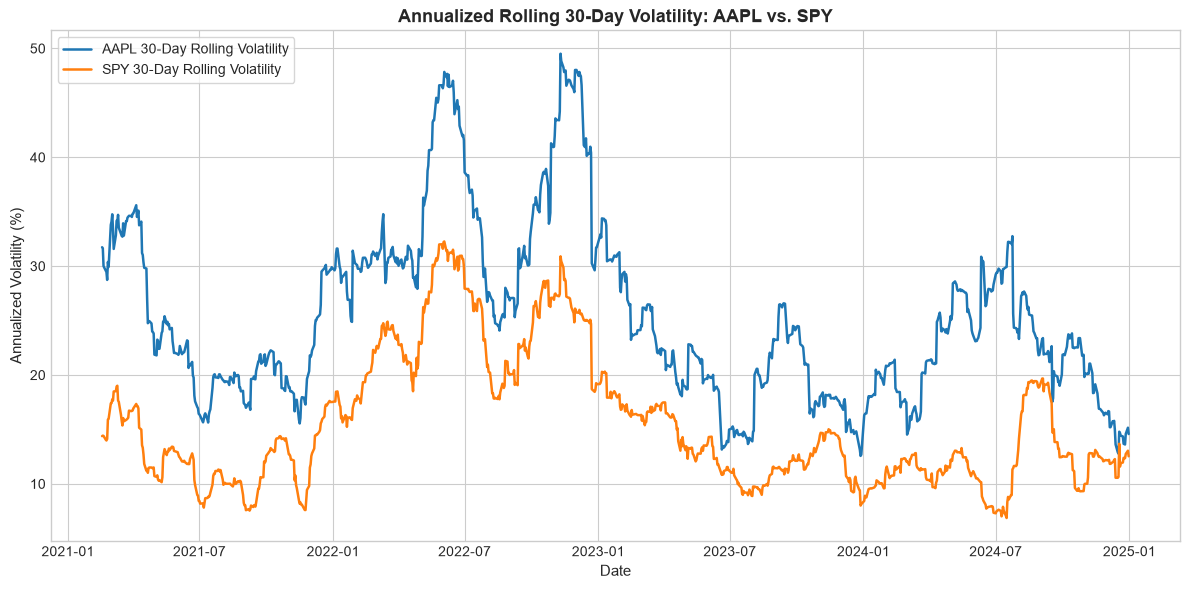

,Daily Volatility (%),Annualized Volatility (%)
Ticker,,
AAPL,1.68,26.60
SPY,1.04,16.48


In [4]:
#IMPORTANT
daily_vol = returns.std()
ann_vol = daily_vol * np.sqrt(252)

#IMPORTANT
rolling_vol_30 = returns.rolling(window=30).std() * np.sqrt(252)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(rolling_vol_30.index, rolling_vol_30['AAPL'] * 100, label='AAPL 30-Day Rolling Volatility', color='#1f77b4', lw=1.8)
ax.plot(rolling_vol_30.index, rolling_vol_30['SPY'] * 100, label='SPY 30-Day Rolling Volatility', color='#ff7f0e', lw=1.8)
ax.set_title('Annualized Rolling 30-Day Volatility: AAPL vs. SPY', fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Annualized Volatility (%)', fontsize=11)
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

pd.DataFrame({
    'Daily Volatility (%)': (daily_vol * 100).round(2),
    'Annualized Volatility (%)': (ann_vol * 100).round(2)
})

### 4. Drawdown Dynamics & Underwater Plot

- A drawdown measures the continuous percentage decline from the asset's preceding historical high-water mark (HWM).
- Maximum Drawdown (MDD) captures the single largest peak-to-trough decline experienced over the investment horizon.
- An underwater plot maps drawdowns continuously through time to reveal drop depth and recovery length.
- **Formulas**:
  $$\text{HWM}_t = \max_{\tau \le t}(P_\tau)$$
  $$D_t = \frac{P_t - \text{HWM}_t}{\text{HWM}_t}$$
  $$\text{MDD} = \min_t(D_t)$$

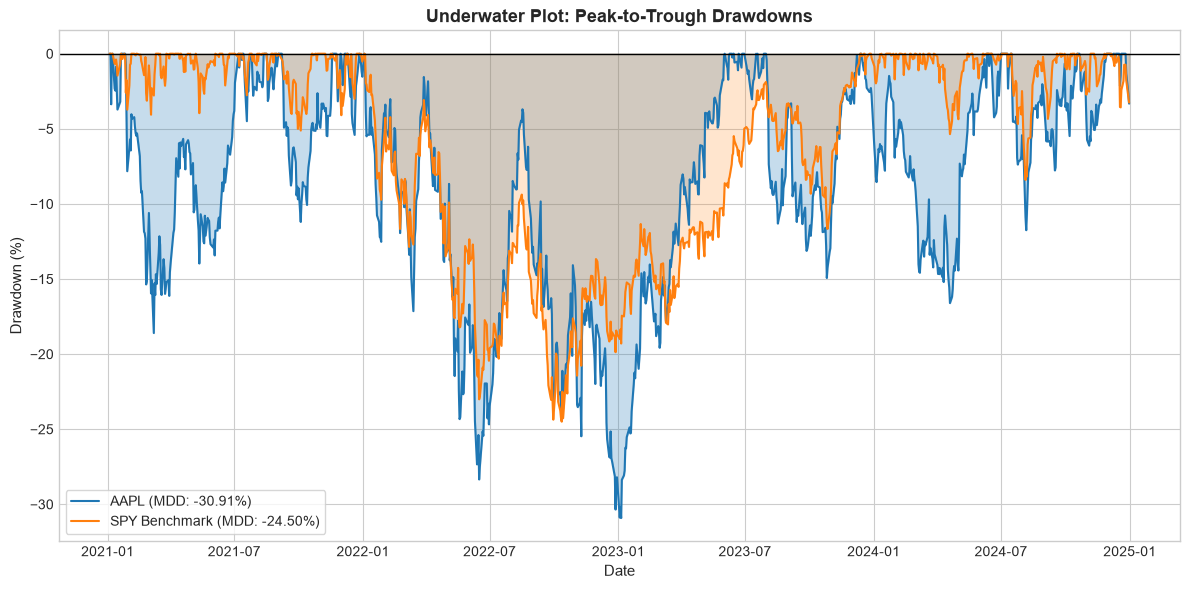

,Max Drawdown (%),Worst Drop Date
AAPL,-30.91,2023-01-05
SPY,-24.50,2022-10-12


In [5]:
#IMPORTANT
hwm_aapl = prices['AAPL'].cummax()
dd_aapl = (prices['AAPL'] - hwm_aapl) / hwm_aapl

hwm_spy = prices['SPY'].cummax()
dd_spy = (prices['SPY'] - hwm_spy) / hwm_spy

#IMPORTANT
mdd_aapl = dd_aapl.min()
mdd_spy = dd_spy.min()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(dd_aapl.index, dd_aapl * 100, label=f"AAPL (MDD: {mdd_aapl * 100:.2f}%)", color='#1f77b4', lw=1.5)
ax.fill_between(dd_aapl.index, dd_aapl * 100, 0, color='#1f77b4', alpha=0.25)

ax.plot(dd_spy.index, dd_spy * 100, label=f"SPY Benchmark (MDD: {mdd_spy * 100:.2f}%)", color='#ff7f0e', lw=1.5)
ax.fill_between(dd_spy.index, dd_spy * 100, 0, color='#ff7f0e', alpha=0.2)

ax.set_title('Underwater Plot: Peak-to-Trough Drawdowns', fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Drawdown (%)', fontsize=11)
ax.axhline(0, color='black', lw=1)
ax.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

pd.DataFrame({
    'Max Drawdown (%)': [round(mdd_aapl * 100, 2), round(mdd_spy * 100, 2)],
    'Worst Drop Date': [dd_aapl.idxmin().strftime('%Y-%m-%d'), dd_spy.idxmin().strftime('%Y-%m-%d')]
}, index=['AAPL', 'SPY'])

### 5. Risk-Adjusted Ratios: Sharpe & Sortino

- The Sharpe ratio standardizes excess return by total standard deviation, penalizing upside and downside volatility symmetrically.
- The Sortino ratio isolates downside deviation below a Minimum Acceptable Return (MAR), leaving upside swings unpenalized.
- **Formulas**:
  $$\text{Sharpe} = \frac{\bar{R}_p - R_f}{\sigma_p} \times \sqrt{252}$$
  $$\delta_{\text{down}} = \sqrt{\frac{1}{N}\sum_{t=1}^N \min(0, R_t - \text{MAR})^2}$$
  $$\text{Sortino} = \frac{\bar{R}_p - \text{MAR}}{\delta_{\text{down}}} \times \sqrt{252}$$

In [6]:
#IMPORTANT
excess_ret_aapl = returns['AAPL'] - rf_daily
excess_ret_spy = returns['SPY'] - rf_daily

#IMPORTANT
sharpe_aapl = (excess_ret_aapl.mean() / returns['AAPL'].std()) * np.sqrt(252)
sharpe_spy = (excess_ret_spy.mean() / returns['SPY'].std()) * np.sqrt(252)

#IMPORTANT
downside_dev_aapl = np.sqrt(np.mean(np.square(np.minimum(0, returns['AAPL'] - rf_daily))))
downside_dev_spy = np.sqrt(np.mean(np.square(np.minimum(0, returns['SPY'] - rf_daily))))

#IMPORTANT
sortino_aapl = (excess_ret_aapl.mean() / downside_dev_aapl) * np.sqrt(252)
sortino_spy = (excess_ret_spy.mean() / downside_dev_spy) * np.sqrt(252)

pd.DataFrame({
    'Annualized Sharpe Ratio': [round(sharpe_aapl, 3), round(sharpe_spy, 3)],
    'Annualized Sortino Ratio': [round(sortino_aapl, 3), round(sortino_spy, 3)],
    'Downside Deviation (%)': [round(downside_dev_aapl * np.sqrt(252) * 100, 2), round(downside_dev_spy * np.sqrt(252) * 100, 2)]
}, index=['AAPL', 'SPY'])

,Annualized Sharpe Ratio,Annualized Sortino Ratio,Downside Deviation (%)
AAPL,0.627,0.916,18.19
SPY,0.633,0.898,11.61


### 6. Dynamic Performance: Rolling 30-Day Sharpe Ratio

- Full-period ratios aggregate performance into a single static figure, masking cyclical outperformance and risk spikes.
- A rolling 30-day window evaluates how risk-adjusted efficiency evolves across changing volatility regimes.
- **Formula**:
  $$\text{Rolling Sharpe}_t = \frac{\bar{R}_{t, 30} - R_f}{\sigma_{t, 30}} \times \sqrt{252}$$

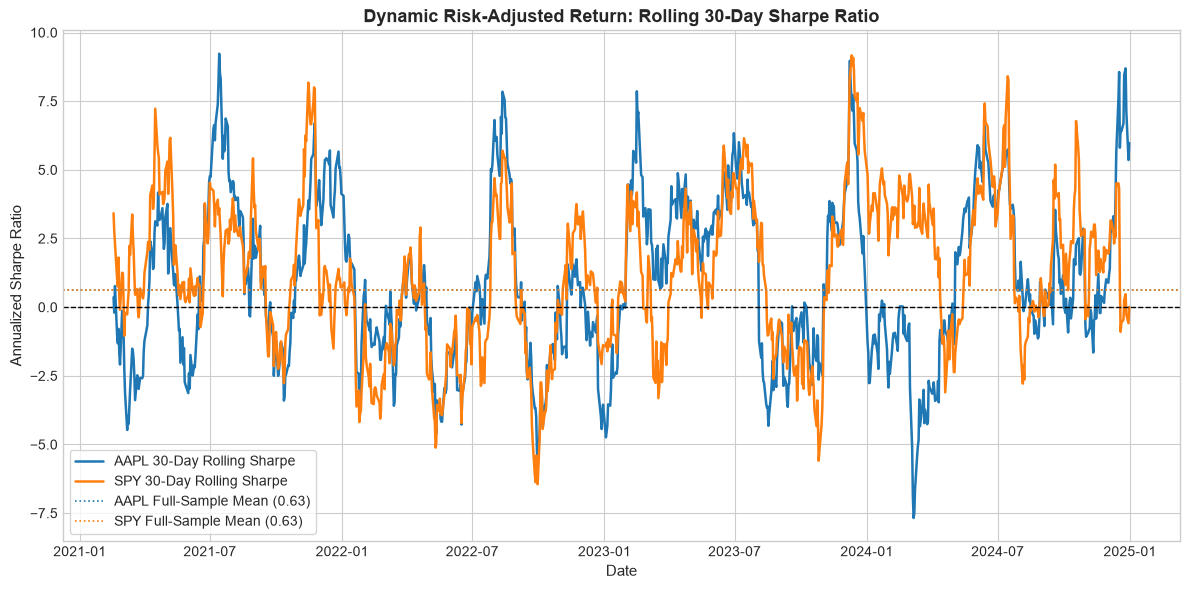

In [7]:
#IMPORTANT
rolling_mean_aapl = returns['AAPL'].rolling(30).mean()
rolling_std_aapl = returns['AAPL'].rolling(30).std()
rolling_sharpe_aapl = ((rolling_mean_aapl - rf_daily) / rolling_std_aapl) * np.sqrt(252)

rolling_mean_spy = returns['SPY'].rolling(30).mean()
rolling_std_spy = returns['SPY'].rolling(30).std()
rolling_sharpe_spy = ((rolling_mean_spy - rf_daily) / rolling_std_spy) * np.sqrt(252)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(rolling_sharpe_aapl.index, rolling_sharpe_aapl, label='AAPL 30-Day Rolling Sharpe', color='#1f77b4', lw=1.8)
ax.plot(rolling_sharpe_spy.index, rolling_sharpe_spy, label='SPY 30-Day Rolling Sharpe', color='#ff7f0e', lw=1.8)
ax.axhline(0, color='black', ls='--', lw=1)
ax.axhline(sharpe_aapl, color='#1f77b4', ls=':', lw=1.2, label=f'AAPL Full-Sample Mean ({sharpe_aapl:.2f})')
ax.axhline(sharpe_spy, color='#ff7f0e', ls=':', lw=1.2, label=f'SPY Full-Sample Mean ({sharpe_spy:.2f})')
ax.set_title('Dynamic Risk-Adjusted Return: Rolling 30-Day Sharpe Ratio', fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Annualized Sharpe Ratio', fontsize=11)
ax.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

### 7. Tail Risk: Historical Value at Risk (VaR)

- Value at Risk calculates the minimum expected loss over a 1-day horizon at a given confidence level $(1 - \alpha)$.
- Derives loss cutoffs directly from empirical return percentiles without assuming normality, capturing true market fat tails.
- **Formula**:
  $$\text{VaR}_{\text{hist}, \alpha} = -q_\alpha(R)$$

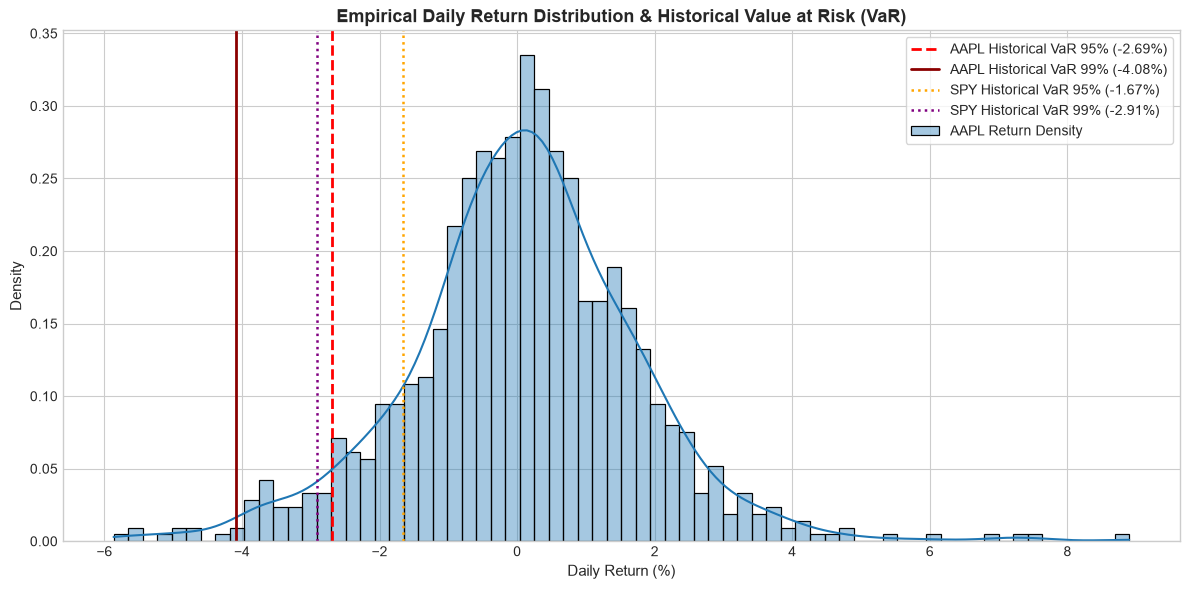

,AAPL Historical 1-Day VaR (%),SPY Historical 1-Day VaR (%)
Confidence Level,,
95%,2.69,1.67
99%,4.08,2.91


In [8]:
#IMPORTANT
var_hist_95_aapl = -np.percentile(returns['AAPL'], 5)
var_hist_99_aapl = -np.percentile(returns['AAPL'], 1)

#IMPORTANT
var_hist_95_spy = -np.percentile(returns['SPY'], 5)
var_hist_99_spy = -np.percentile(returns['SPY'], 1)

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(returns['AAPL'] * 100, bins=70, kde=True, color='#1f77b4', stat='density', alpha=0.4, label='AAPL Return Density', ax=ax)

ax.axvline(-var_hist_95_aapl * 100, color='red', ls='--', lw=2, label=f'AAPL Historical VaR 95% (-{var_hist_95_aapl * 100:.2f}%)')
ax.axvline(-var_hist_99_aapl * 100, color='darkred', ls='-', lw=2, label=f'AAPL Historical VaR 99% (-{var_hist_99_aapl * 100:.2f}%)')
ax.axvline(-var_hist_95_spy * 100, color='orange', ls=':', lw=1.8, label=f'SPY Historical VaR 95% (-{var_hist_95_spy * 100:.2f}%)')
ax.axvline(-var_hist_99_spy * 100, color='purple', ls=':', lw=1.8, label=f'SPY Historical VaR 99% (-{var_hist_99_spy * 100:.2f}%)')

ax.set_title('Empirical Daily Return Distribution & Historical Value at Risk (VaR)', fontsize=13, fontweight='bold')
ax.set_xlabel('Daily Return (%)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

pd.DataFrame({
    'Confidence Level': ['95%', '99%'],
    'AAPL Historical 1-Day VaR (%)': [round(var_hist_95_aapl * 100, 2), round(var_hist_99_aapl * 100, 2)],
    'SPY Historical 1-Day VaR (%)': [round(var_hist_95_spy * 100, 2), round(var_hist_99_spy * 100, 2)]
}).set_index('Confidence Level')

### 8. Capital Asset Pricing Model (CAPM): Beta & Jensen's Alpha

- Regresses asset excess returns against benchmark market excess returns.
- Beta ($\beta$) measures systematic market sensitivity; alpha ($\alpha$) captures risk-adjusted return independent of broad market swings.
- $R^2$ indicates the proportion of total asset variance explained by benchmark movements.
- **Formulas**:
  $$R_{\text{AAPL}, t} - R_f = \alpha + \beta (R_{\text{SPY}, t} - R_f) + \epsilon_t$$
  $$\beta = \frac{\text{Cov}(R_{\text{AAPL}}, R_{\text{SPY}})}{\text{Var}(R_{\text{SPY}})}$$
  $$\alpha_{\text{ann}} = \alpha_{\text{daily}} \times 252$$

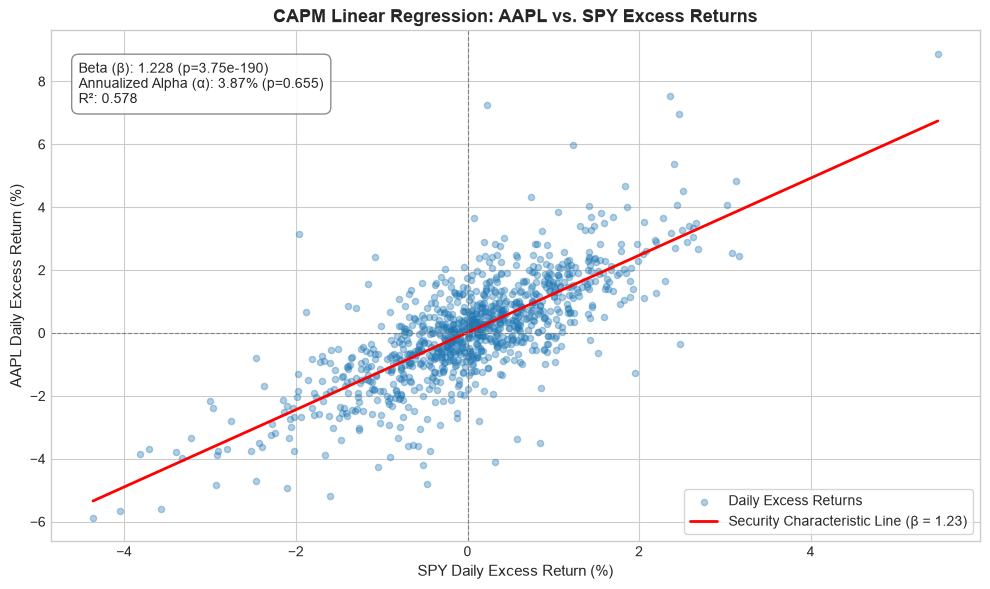

In [9]:
#IMPORTANT
y = returns['AAPL'] - rf_daily
x = sm.add_constant(returns['SPY'] - rf_daily)
model = sm.OLS(y, x).fit()

#IMPORTANT
alpha_daily = model.params['const']
beta = model.params.iloc[1]
alpha_ann = alpha_daily * 252
r2 = model.rsquared
p_alpha = model.pvalues['const']
p_beta = model.pvalues.iloc[1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter((returns['SPY'] - rf_daily) * 100, (returns['AAPL'] - rf_daily) * 100, alpha=0.35, color='#1f77b4', s=20, label='Daily Excess Returns')
x_vals = np.linspace((returns['SPY'] - rf_daily).min(), (returns['SPY'] - rf_daily).max(), 100)
y_vals = alpha_daily + beta * x_vals
ax.plot(x_vals * 100, y_vals * 100, color='red', lw=2, label=f'Security Characteristic Line (β = {beta:.2f})')

diag_str = f"Beta (β): {beta:.3f} (p={p_beta:.2e})\nAnnualized Alpha (α): {alpha_ann * 100:.2f}% (p={p_alpha:.3f})\nR²: {r2:.3f}"
ax.text(0.03, 0.94, diag_str, transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

ax.set_title("CAPM Linear Regression", fontsize=13, fontweight='bold')
ax.set_xlabel('SPY Daily Excess Return (%)', fontsize=11)
ax.set_ylabel('AAPL Daily Excess Return (%)', fontsize=11)
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.axvline(0, color='gray', ls='--', lw=0.8)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

### 9. Advanced Metric: Probabilistic Sharpe Ratio (PSR)

- Standard Sharpe assumes returns are independent and normally distributed, creating bias when track records feature skewness or heavy fat tails.
- Formulated by Marcos López de Prado, the Probabilistic Sharpe Ratio adjusts for track record length $n$, sample skewness $\hat{\gamma}_3$, and sample kurtosis $\hat{\gamma}_4$.
- Evaluates the probability that the estimated Sharpe ratio genuinely exceeds a reference benchmark threshold $SR^*$.
- **Formula**:
  $$\text{PSR}(SR^*) = \Phi\left( \frac{(\widehat{SR} - SR^*)\sqrt{n - 1}}{\sqrt{1 - \hat{\gamma}_3 \widehat{SR} + \frac{\hat{\gamma}_4 - 1}{4}\widehat{SR}^2}} \right)$$
  where $\Phi(\cdot)$ is the standard normal cumulative distribution function and $\widehat{SR}$ is calculated on the unannualized return frequency.

In [10]:
def compute_psr(daily_returns, rf_daily, benchmark_sr_ann=0.0):
    excess = daily_returns - rf_daily
    n = len(excess)
    
    #IMPORTANT
    sr_daily = excess.mean() / excess.std()
    sr_ann = sr_daily * np.sqrt(252)
    gamma_3 = stats.skew(excess)
    gamma_4 = stats.kurtosis(excess, fisher=False)
    sr_star_daily = benchmark_sr_ann / np.sqrt(252)
    
    #IMPORTANT
    denom = np.sqrt(1.0 - gamma_3 * sr_daily + ((gamma_4 - 1.0) / 4.0) * (sr_daily ** 2))
    z_score = ((sr_daily - sr_star_daily) * np.sqrt(n - 1)) / denom
    psr = stats.norm.cdf(z_score)
    
    return {
        'Observations (N)': n,
        'Annualized SR': round(sr_ann, 3),
        'Skewness': round(gamma_3, 3),
        'Kurtosis': round(gamma_4, 3),
        'PSR vs. SR*=0 (%)': round(psr * 100, 2)
    }

#IMPORTANT
psr_aapl = compute_psr(returns['AAPL'], rf_daily, benchmark_sr_ann=0.0)
psr_spy = compute_psr(returns['SPY'], rf_daily, benchmark_sr_ann=0.0)
psr_aapl_vs_spy = compute_psr(returns['AAPL'], rf_daily, benchmark_sr_ann=sharpe_spy)

summary_psr = pd.DataFrame([psr_aapl, psr_spy], index=['AAPL', 'SPY'])
summary_psr['PSR vs. SPY Benchmark (%)'] = [psr_aapl_vs_spy['PSR vs. SR*=0 (%)'], np.nan]
summary_psr

,Observations (N),Annualized SR,Skewness,Kurtosis,PSR vs. SR*=0 (%),PSR vs. SPY Benchmark (%)
AAPL,1004,0.627,0.148,5.075,89.48,49.52
SPY,1004,0.633,-0.206,4.922,89.54,NaN


### Module Summary & Metric Hierarchy

- **Return Foundations**: Compares simple returns and log returns, isolating residual comovement against benchmark index swings.
- **Total Growth & Volatility**: CAGR accounts for compounding; annualized volatility normalizes return variance to a standard annual basis.
- **Drawdown & Asymmetry**: Max Drawdown and underwater curves capture tail stress; Sortino refines Sharpe by penalizing only downside variance.
- **Systematic Exposure**: CAPM regression isolates systematic market beta from idiosyncratic manager alpha.
- **Statistical Rigor**: The Probabilistic Sharpe Ratio verifies whether performance is statistically genuine given sample length, skewness, and kurtosis.